# Applicant-to-Program Funnel and impact Dashboard for Pwani Teknowgalz


## Business Understanding
Pwani Teknowgalz was founded in 2015/2016 originally to close the gender gap in STEM at the Technical University of Mombasa. It has since grown into a recognized digital innovation hub(selected under Kenya’s DigiKen initiative) delivering programs including STEM Café’ Kenya across counties including Mombasa, Nairobi, Kisumu and Lamu.

## Problem Statement
Pwani Teknowgalz has received over 20,000 program applications since inception but has only been able to enroll about 15% of applicants (6,800 young women). The organization has publicly committed to reaching 50% applicants by the end of 2026. At the present, applicant, enrollment and program data appear to be tracked separately across multiple programs and counties with no unified view of where the funnel breaks down or what resource constraints are a limiting capacity. Without this visibility it is difficult for the organization to prioritize outreach, allocate resources or make an evidence-based case to funders.

## Proposed Solution
This project aims at developing a centralized analytics solution that consolidates applicant, enrollment, program and resource data into a single clean dataset from the database. Moreover, it will provide an interactive dashboard maintainable by the organization staff that will enable the organization to monitor applicant journey, identify enrollment bottlenecks, understand who is beinG underserved, track resource constraint and measure progress towards its 2026 goal of enrolling 50% applicants.

## Project Objectives

To Consolidate and clean applicant and program-participation data across Pwani Teknowgalz’s programs and counties into a single analyzable dataset.
To Quantify the applicant to enrollment funnel and identify the stages, programs or regions with the largest drop off.
To identify patterns in who is and who is not being reached relative to the applicant pool.
To surface resources or capacity constraints that limits how many applicants can be enrolled.
To build an interactive dashboard that lets staff track progress towards the 2026 goal.
To hand over a lightweight, non-technical process staff can use to keep the dashboard updated after the project ends.




In [2]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

In [3]:
# Load applicants data 
df= pd.read_csv("Applicants_data.csv")
df.head()


,applicant_id,first_name,last_name,age,gender,county_id,education_level,email
0,APP00001,Sharon,Wambui,33,female,C001,Bachelor's,sharonwambuiapp00001@gmail.com
1,APP00002,Irene,Barasa,23,Female,C002,Diploma,irenebarasaapp00002@gmail.com
2,APP00003,Faith,Maina,30,Female,C007,Diploma,faithmainaapp00003@gmail.com
3,APP00004,Rose,Ndungu,29,Female,C008,Master's,rosendunguapp00004@gmail.com
4,APP00005,Jackline,Munyao,18,Female,C007,NaN,jacklinemunyaoapp00005@gmail.com


In [4]:
# Data Quality Check
df.columns
df.describe()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   applicant_id     5000 non-null   object
 1   first_name       5000 non-null   object
 2   last_name        5000 non-null   object
 3   age              5000 non-null   int64 
 4   gender           5000 non-null   object
 5   county_id        5000 non-null   object
 6   education_level  4970 non-null   object
 7   email            5000 non-null   object
dtypes: int64(1), object(7)
memory usage: 312.6+ KB


This data set contains 8 columns and 5000 rows. It means we have a record of 5000 applicants. Only age has numerical values. Let's proceed with the cleaning

In [5]:
# Data Cleaning
# Check for null values
missing_values=pd.DataFrame({
    "Column": df.columns,
    "missing values": df.isnull().sum().values
})
missing_values



,Column,missing values
0,applicant_id,0
1,first_name,0
2,last_name,0
3,age,0
4,gender,0
5,county_id,0
6,education_level,30
7,email,0


In [6]:
# Check for duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

We found out that we have some null entries in education level, no duplicated values and some column entries are mixed up(Gender: upper case and lower case).
We will resolve these issues by replacing the null entries with (KCSE level) since it is an important feature in our dataset . Standardize the entries by using a title case and autofit values in our cell to obtain a consistent dataset. Let us check applications data.

In [7]:
# Display applications data
df= pd.read_csv("Applications_data.csv")
df.head()

,application_id,applicant_id,program_id,application_date,application_status,drop_off_reason
0,APL00001,APP00001,P007,8/9/2025,Applied,Incomplete Application
1,APL00002,APP00002,P002,4/24/2025,Interviewed,Cohort Full
2,APL00003,APP00003,P005,2/27/2024,Enrolled,NaN
3,APL00004,APP00004,P004,8/13/2025,Applied,Did Not Meet Requirements
4,APL00005,APP00005,P002,7/21/2024,Interviewed,Cohort Full


In [8]:
# Data Quality Check
df.columns
df.describe()


,application_id,applicant_id,program_id,application_date,application_status,drop_off_reason
count,5000,5000,5000,5000,5000,4270
unique,5000,5000,8,485,4,9
top,APL00001,APP00001,P004,2/15/2025,Applied,Incomplete Application
freq,1,1,1080,23,2024,765


In [9]:
df.shape

(5000, 6)

Applications data has 5000 rows and 6 columns but according to our data, we have some null entries in drop off reason( 730 entries).
Now we proceed with cleaning our data using Power Query in Excel then use SQL to merge the data we need.

We cleaned each file separately let us display the content then merge


In [10]:
# Display the cleaned files
applicants = pd.read_csv("Applicants_data_cleaned.csv")
applicants.head()
applicants.describe()


,age
count,5000.000000
mean,24.176000
std,4.681475
min,18.000000
25%,20.000000
50%,23.000000
75%,27.000000
max,35.000000


In [11]:
# Applications data
Applications = pd.read_csv("Applications_data.csv")
Applications.head()
Applications.describe()

,application_id,applicant_id,program_id,application_date,application_status,drop_off_reason
count,5000,5000,5000,5000,5000,4270
unique,5000,5000,8,485,4,9
top,APL00001,APP00001,P004,2/15/2025,Applied,Incomplete Application
freq,1,1,1080,23,2024,765


In [12]:
# Application data cleaning
# Fill missing drop-off reasons based on application status
Applications.loc[
    (Applications["application_status"] == "Applied") &
    (Applications["drop_off_reason"].isna()),
    "drop_off_reason"
] = "Incomplete Application"

Applications.loc[
    (Applications["application_status"] == "Qualified") &
    (Applications["drop_off_reason"].isna()),
    "drop_off_reason"
] = "Could Not Be Reached"
Applications.loc[
    (Applications["application_status"] == "Interviewed") &
    (Applications["drop_off_reason"].isna()),
    "drop_off_reason"
] = "Declined Offer"
# Save the cleaned dataset
Applications.to_csv("Applications_clean.csv", index=False)

print("Applications table cleaned successfully!")




Applications table cleaned successfully!


In the code above we cleaned Applications data by eliminating the drop off reason null entries

In [13]:
# Applications data check
Applications_data = pd.read_csv("Applications_clean.csv")
Applications_data.describe()

,application_id,applicant_id,program_id,application_date,application_status,drop_off_reason
count,5000,5000,5000,5000,5000,4277
unique,5000,5000,8,485,4,9
top,APL00001,APP00001,P004,2/15/2025,Applied,Incomplete Application
freq,1,1,1080,23,2024,771


The only null drop off reason entries are those where application_status is "enrolled" since the applicants were not dropped off. now let's select the data we need from the 2 tables and consolidate them using SQL.

In [14]:
# Connect to the SQLite database
conn = sqlite3.connect("pwani.db")

# Load the cleaned CSV files
applicants = pd.read_csv("Applicants_data_cleaned.csv")
applications = pd.read_csv("Applications_clean.csv")

# Write the DataFrames to SQLite
# If the tables already exist, they will be replaced.
applicants.to_sql(
    "Applicants_clean",
    conn,
    if_exists="replace",
    index=False
)

applications.to_sql(
    "Applications_clean",
    conn,
    if_exists="replace",
    index=False
)

print("Cleaned tables imported successfully!")

# SQL query to create the master dataset
query = """
SELECT
    a.applicant_id,
    a.age,
    a.gender,
    c.county_name,
    a.education_level,
    ap.program_id,
    p.program_name,
    ap.application_date,
    ap.application_status,
    ap.drop_off_reason

FROM Applicants_clean AS a

INNER JOIN Applications_clean AS ap
    ON a.applicant_id = ap.applicant_id

INNER JOIN Counties AS c
    ON a.county_id = c.county_id

INNER JOIN Programs AS p
    ON ap.program_id = p.program_id;
"""

# Read SQL query into a DataFrame
master_dataset = pd.read_sql_query(query, conn)

# Preview the first few rows
print(master_dataset.head())

# Check dataset dimensions
print(f"\nRows: {master_dataset.shape[0]}")
print(f"Columns: {master_dataset.shape[1]}")

# Export to CSV
master_dataset.to_csv("consolidated_dataset.csv", index=False)

print("\nMaster dataset created and exported successfully!")

# Close the database connection
conn.close()

Cleaned tables imported successfully!
  applicant_id  age  gender county_name education_level program_id  \
0     APP00001   33  Female     Mombasa      Bachelor's       P007   
1     APP00002   23  Female       Kwale         Diploma       P002   
2     APP00003   30  Female     Nairobi         Diploma       P005   
3     APP00004   29  Female      Nakuru        Master's       P004   
4     APP00005   18  Female     Nairobi            KCSE       P002   

           program_name application_date application_status  \
0  Women Digital Skills         8/9/2025            Applied   
1          Technovation        4/24/2025        Interviewed   
2          Django Girls        2/27/2024           Enrolled   
3      Africa Code Week        8/13/2025            Applied   
4          Technovation        7/21/2024        Interviewed   

             drop_off_reason  
0     Incomplete Application  
1                Cohort Full  
2                       None  
3  Did Not Meet Requirements  
4      

We first converted our cleaned csv files to Tables, implemented inner join to consolidate the data we need from different tables to a master table. then we converted the table data to a csv file so that we can analyse it.

## Data Analysis

In [15]:
# Load the dataset
df=pd.read_csv("consolidated_dataset.csv")
df.head()

,applicant_id,age,gender,county_name,education_level,program_id,program_name,application_date,application_status,drop_off_reason
0,APP00001,33,Female,Mombasa,Bachelor's,P007,Women Digital Skills,8/9/2025,Applied,Incomplete Application
1,APP00002,23,Female,Kwale,Diploma,P002,Technovation,4/24/2025,Interviewed,Cohort Full
2,APP00003,30,Female,Nairobi,Diploma,P005,Django Girls,2/27/2024,Enrolled,NaN
3,APP00004,29,Female,Nakuru,Master's,P004,Africa Code Week,8/13/2025,Applied,Did Not Meet Requirements
4,APP00005,18,Female,Nairobi,KCSE,P002,Technovation,7/21/2024,Interviewed,Cohort Full


In [16]:
# Data Inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   applicant_id        5000 non-null   object
 1   age                 5000 non-null   int64 
 2   gender              5000 non-null   object
 3   county_name         5000 non-null   object
 4   education_level     5000 non-null   object
 5   program_id          5000 non-null   object
 6   program_name        5000 non-null   object
 7   application_date    5000 non-null   object
 8   application_status  5000 non-null   object
 9   drop_off_reason     4277 non-null   object
dtypes: int64(1), object(9)
memory usage: 390.8+ KB


## Exploratory Analysis

In [17]:
# Education level distribution
df['education_level'].value_counts()

education_level
KCSE           1901
Diploma        1115
Certificate    1031
Bachelor's      794
Master's        159
Name: count, dtype: int64

From the analysis above most of the applicants are KCSE Graduates. This means that continuing outreach initiatives targeting this group could help increase applications and support the organization's 2026 participation goals.

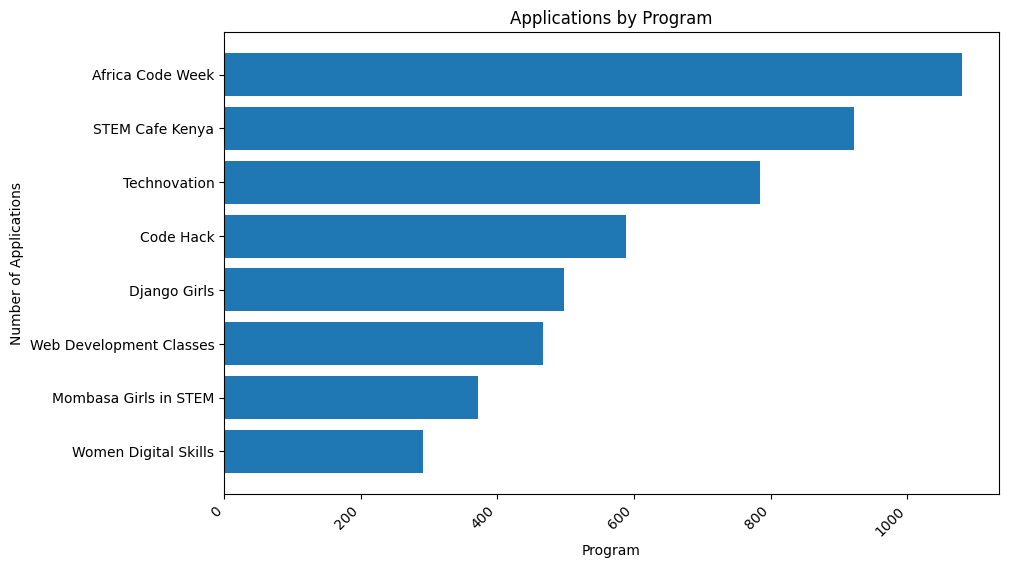

In [18]:
# Program Popularity
programs= df['program_name'].value_counts().sort_values(ascending=True)
programs
plt.figure(figsize=(10,6))

plt.barh(programs.index, programs.values)

plt.title("Applications by Program")
plt.xlabel("Program")
plt.ylabel("Number of Applications")

plt.xticks(rotation=45, ha="right")

plt.show()

From the bar chart, it is clear that Africa Code Week is the most popular program. That means increasing it's capacity will make Pwani Teknowgalz enroll more students and it will
be able to reach even more students since most students are interested in that program.

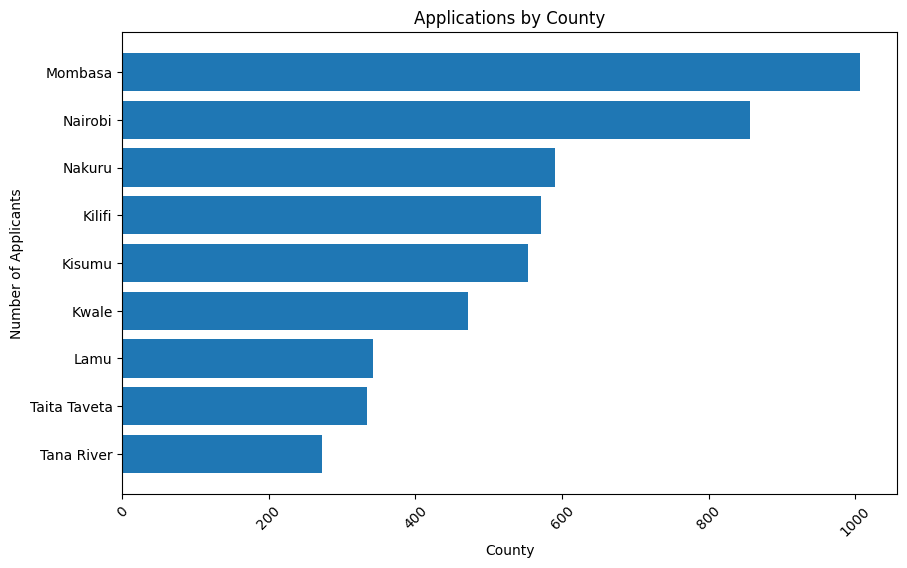

In [19]:
# Applications by Counties
counties = df["county_name"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10,6))

plt.barh(counties.index, counties.values)

plt.title("Applications by County")
plt.xlabel("County")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=45)

plt.show()


From the chart, Mombasa accounts for most applicants and Tana River is the least reached County. To reach even more students, Pwani Teknowgalz should increase it's Advertisement Campaigns in Tana River, add a Branch there while increasing learning resources in Mombasa to carter for the large number of applicants so that more can be enrolled successfully.

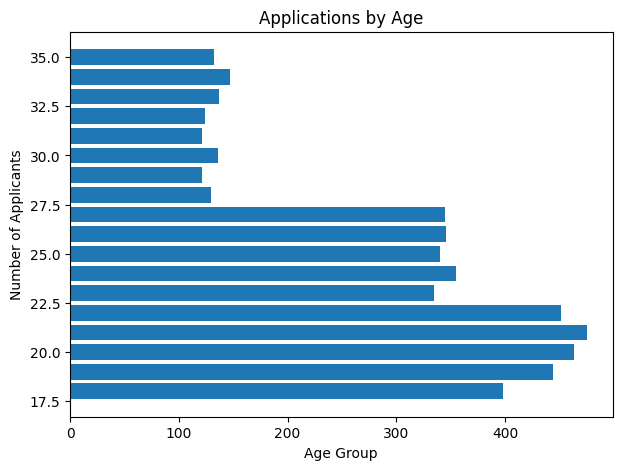

In [20]:
# Application by Age
age_groups = df["age"].value_counts().sort_values()

plt.figure(figsize=(7,5))

plt.barh(age_groups.index, age_groups.values)

plt.title("Applications by Age")
plt.xlabel("Age Group")
plt.ylabel("Number of Applicants")

plt.show()


Age Analysis shows that young people(18 to 28) tend to have highest tendency of applications. To maximize application rate, The organization can introduce fun and engaging activities in their programs such as Game development challenges and competitions to keep participants motivated.

## Enrollment analysis

In [21]:

# Calculate totals
total_applicants = len(df)
total_enrolled = (df["application_status"] == "Enrolled").sum()
enrollment_rate = (total_enrolled / total_applicants) * 100
print (enrollment_rate, "%")

14.46 %


From 5000 applicants, only 14.46% were enrolled

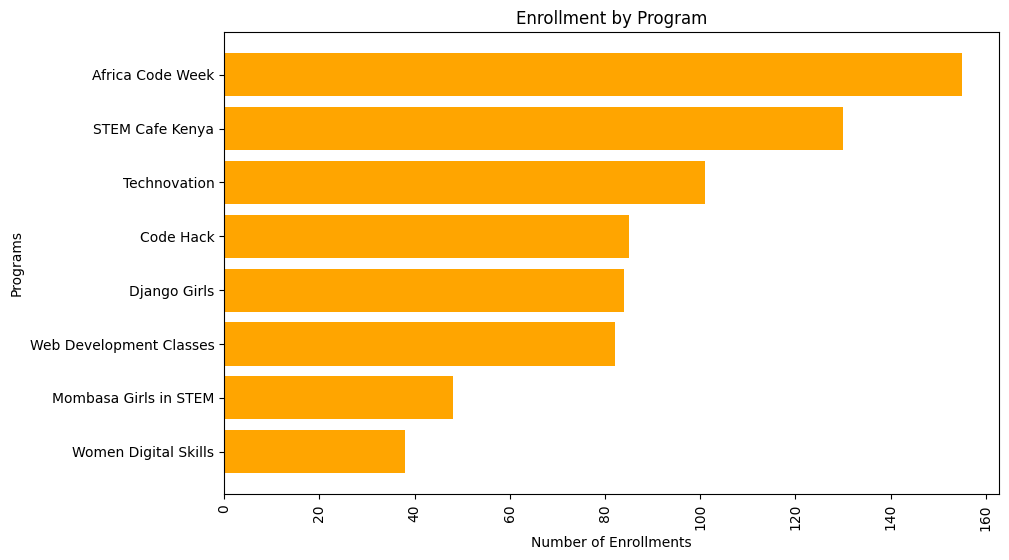

In [22]:
# Enrollment by Program
enrolled= df[df["application_status"] == "Enrolled"]
enrollment_by_program = enrolled["program_name"].value_counts().sort_values(ascending=True)
# plot the graph
plt.figure(figsize=(10,6))
plt.barh(enrollment_by_program.index, enrollment_by_program.values, color='orange')
plt.title("Enrollment by Program")
plt.xlabel("Number of Enrollments")
plt.ylabel("Programs")
plt.xticks(rotation=90)
plt.show()

Africa code week recorded highest enrollment rate and women digital skills the least. 

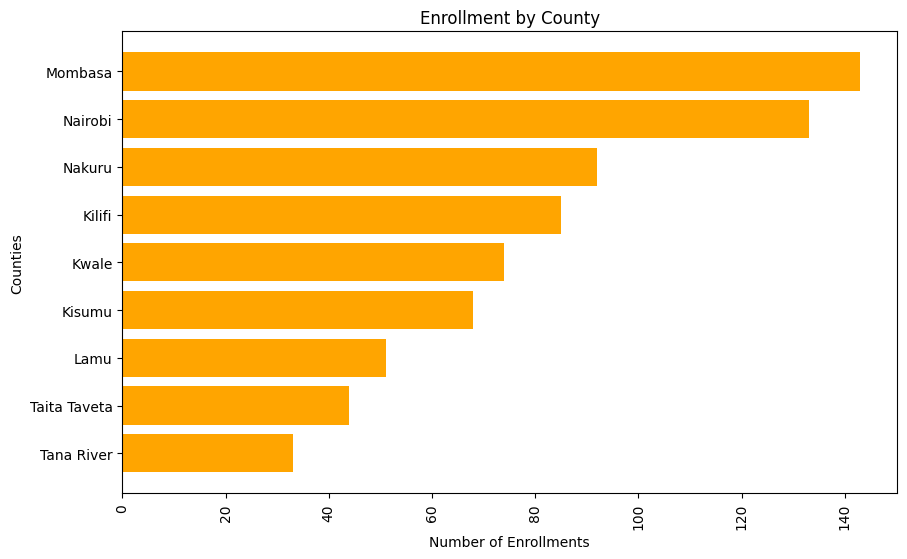

In [23]:
# Enrollment by Counties
enrollment_by_county =enrolled["county_name"].value_counts().sort_values(ascending=True)
plt.figure(figsize=(10,6))
plt.barh(enrollment_by_county.index, enrollment_by_county.values, color='orange')
plt.title("Enrollment by County")
plt.xlabel("Number of Enrollments")
plt.ylabel("Counties")
plt.xticks(rotation=90)
plt.show()

Mombasa records highest enrollments too and Tana River the least enrollments.

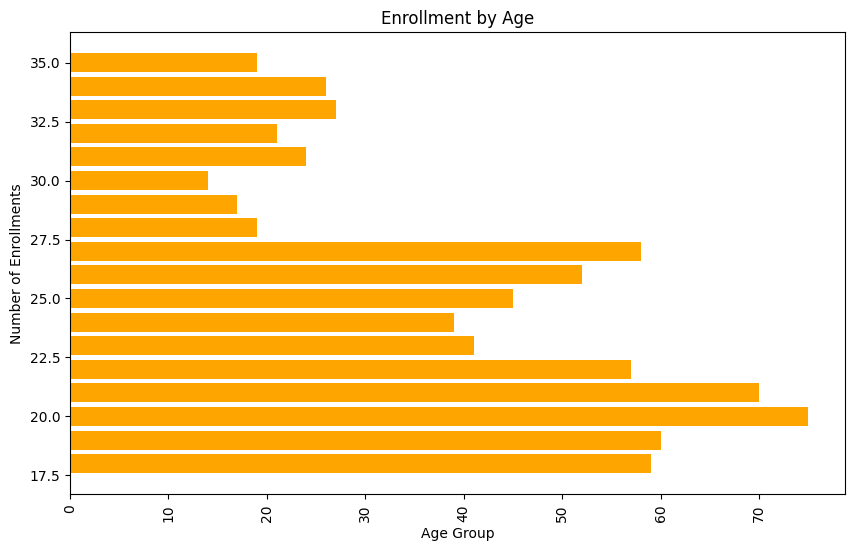

In [24]:
# Enrollment by Age
enrollment_by_age = enrolled.groupby("age").size().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.barh(enrollment_by_age.index, enrollment_by_age.values, color='orange')
plt.title("Enrollment by Age")
plt.xlabel("Age Group")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=90)
plt.show()

The youngest age range are the ones being enrolled the most.

## Drop off analysis

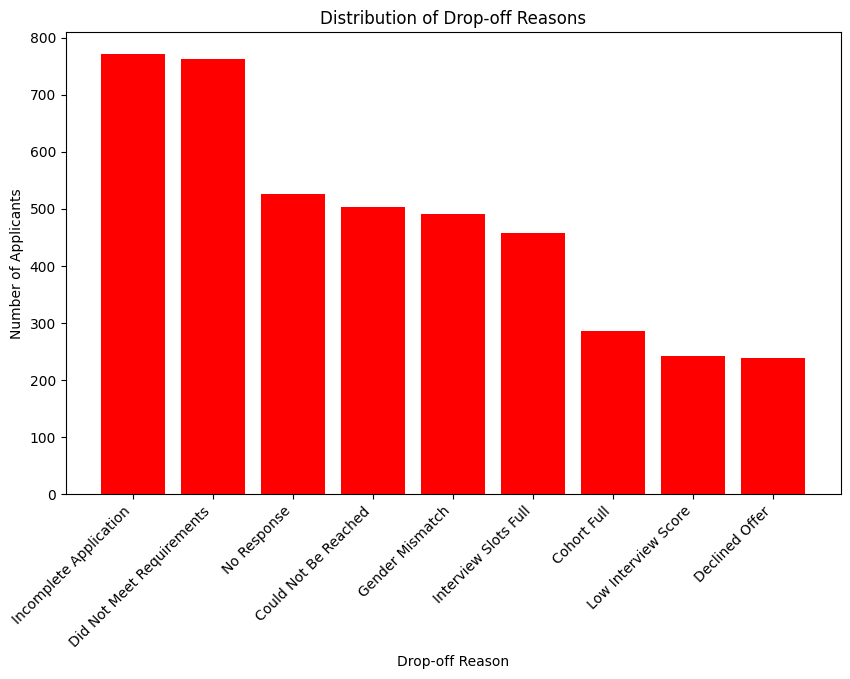

In [25]:
# Filter applicants who were not enrolled
drop_off = df[df["application_status"] != "Enrolled"]

drop_reason = drop_off["drop_off_reason"].value_counts().sort_values(ascending=False)

drop_reason
plt.figure(figsize=(10,6))

plt.bar(
    drop_reason.index,
    drop_reason.values,
    color="red"
)

plt.title("Distribution of Drop-off Reasons")
plt.xlabel("Drop-off Reason")
plt.ylabel("Number of Applicants")


plt.xticks(rotation=45, ha="right")

plt.show()

From the analysis, The reason why most applicants are dropped off is because they did not complete application. Introducing a mechanism where the organisation reminds applicants with incomplete application to a finish applying will solve this problem. While advertising for the intake the organization should clearly state the requirements so that applicants are not dropped of due to unmet requirements. The applicants should also provide alternate phone numbers for communication in case the applicant is unreachable on the initial phone number

In [26]:
# Drop percentage
drop_percentage = (
    drop_reason / drop_reason.sum() * 100
).round(2)

drop_percentage

drop_off_reason
Incomplete Application       18.03
Did Not Meet Requirements    17.82
No Response                  12.30
Could Not Be Reached         11.76
Gender Mismatch              11.48
Interview Slots Full         10.71
Cohort Full                   6.69
Low Interview Score           5.66
Declined Offer                5.56
Name: count, dtype: float64